# Curves, conventions and the limits of a one-swap hedge

## Summary

Under the explicit illustrative inputs, a bond priced at **103.195569 per 100** is parallel-DV01-neutralized with **1.009745 units** of a payer swap (each unit has notional 100). The largest absolute residual among five frozen instantaneous scenarios is **0.071261 per 100**, in **local_7y**. A single parallel hedge leaves curve-shape and convexity risk.

## Context and methods

# From curve quotes to frozen hedge P&L

A yield curve is a mapping from dated cash flows to present value, not just a line through
rates. Deposits, par swaps, zero rates and discount factors encode different objects. This
study begins with explicit constructed par quotes and asks which price/risk differences arise
when assumptions change.

## Contract and convention table

| Item | Primary numerical assumption |
|---|---|
| Valuation | 15 September 2026; no elapsed time in scenarios |
| Currency/notional | USD; 100 bond face and 100 per swap unit |
| Calendar/adjustment | US GovernmentBond; Modified Following |
| Settlement | Zero days for aligned independent PV comparisons |
| Discount inputs | 1–10Y illustrative SOFR-style OIS par quotes; annual fixed, Actual/360 |
| Discount interpolation | Log-linear discount factors; no required extrapolation |
| Projection | Synthetic USD 3M term index; zero fixing lag; Actual/360 |
| Swap | Forward-start one business day; 7Y payer; annual fixed, quarterly floating |
| Floating coupons | Indexed coupons, explicit index value/maturity dates |
| Bond | 4% coupon; semiannual; Actual/Actual ISMA; March 2026–September 2033 |
| Bond spread | Zero credit/liquidity spread, an illustration rather than a Treasury CUSIP |
| FX | USD per EUR; spot 1.10; EUR flat continuous 2.5%; zero basis assumed |

The synthetic term index is not a surviving USD LIBOR contract. SOFR's overnight reference
rate is not a complete OIS quote strip. The fixture has no claim to matching live quotes,
CSA terms, benchmark fixings or executable collateralized funding.

## Calibration and independent valuation

QuantLib bootstraps each instrument to its quoted par rate. Projection helpers discount
using the separate OIS curve. Repricing errors must remain below 1e-8 in decimal rate units.
This verifies internal consistency, not the correctness of unobserved market inputs.

The bond's independent PV sums coupon/principal amounts times discount factors. The payer
swap adds floating coupons and subtracts fixed coupons. Each floating rate comes from the
projection ratio (P(value)/P(maturity)-1)/index_accrual and is multiplied by the coupon's
actual accrual before discounting. Holiday adjustments can make those periods differ;
using an implicit par-coupon approximation in one calculation and indexed coupons in another
creates a small genuine convention difference. Both calculations now use indexed coupons.

## Risk has an object and a unit

Signed quote DV01 is [PV(q+1bp)-PV(q-1bp)]/2: currency per positive basis point, with curves
rebuilt. For a fixed-rate bond it is negative. Quote buckets separately perturb discount and
projection pillars. This differs from a yield bump and from a parallel continuous zero spread.
For the latter, an independent derivative is -sum(t CF D) times 1e-4. Bumps of .1, 1 and 5 bp
check finite-difference stability; second differences quantify curvature in currency/bp squared.

## Hedging is a local statement

Hold h=-bond_DV01/swap_DV01 swap units. Freeze h and the swap coupon before every scenario.
Parallel neutrality removes one first-order direction; it does not neutralize a full vector
of quote risks. Large shocks also expose convexity. The scenario table reports exact
revaluation, quote-bucket first order, and a second-order parallel approximation. None includes
carry, roll-down or intervening cash flows.

FX parity follows from matching dated currency cash flows: F=S D_EUR/D_USD; long-EUR forward
PV in USD is S D_EUR-K D_USD. The fair strike has zero PV under the declared no-basis assumptions.
An executable transaction needs observed bid/ask, collateral, funding and settlement terms.

[Generated valuation and hedge evidence](docs/02-results.md) · [Full protocol and tolerances](research/PROTOCOL.md).


### Recompute from pinned inputs

Runs the maintained pipeline, reusing matching checkpoints where available. No notebook-only model logic.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image
from research.run_study import main
from research.common import ROOT, RESULTS, FIGURES
main()

Under the explicit illustrative inputs, a bond priced at **103.195569 per 100** is parallel-DV01-neutralized with **1.009745 units** of a payer swap (each unit has notional 100). The largest absolute residual among five frozen instantaneous scenarios is **0.071261 per 100**, in **local_7y**. A single parallel hedge leaves curve-shape and convexity risk.


## Data

Input provenance records the exact vintage or the explicitly illustrative fixture. Retrieval dates do not imply historical availability.

In [2]:
manifest = json.loads((ROOT / "research/data/input_manifest.json").read_text())
display(Markdown("Input kind: **" + manifest.get("kind", "observed adjusted-close snapshots") + "**"))
sources = pd.DataFrame(manifest.get("snapshots", manifest.get("inputs", [])))
columns = [c for c in ["ticker", "rows", "first_date", "last_date", "path"] if c in sources]
display(sources[columns].head(10))

Input kind: **illustrative_not_market**

,path
0,research/data/illustrative_quotes.csv


## Results

In [3]:
import re
text = (ROOT / "docs/02-results.md").read_text()
text = re.sub(r"!\[[^\]]*\]\([^)]*\)", "", text)
display(Markdown(text.replace("../research/", "research/").replace("(01-methods.md)", "(docs/01-methods.md)")))

# Curves, conventions and the limits of a one-swap hedge

Under the explicit illustrative inputs, a bond priced at **103.195569 per 100** is parallel-DV01-neutralized with **1.009745 units** of a payer swap (each unit has notional 100). The largest absolute residual among five frozen instantaneous scenarios is **0.071261 per 100**, in **local_7y**. A single parallel hedge leaves curve-shape and convexity risk.

These are numerical model results from constructed quotes dated 15 September 2026. No residual is an observed mispricing or executable trading opportunity.

## Independent valuation and calibration

| instrument | quantlib_pv | independent_pv | residual | clean | accrued | dirty |
| --- | --- | --- | --- | --- | --- | --- |
| bond | 103.196 | 103.196 | 2.84217e-14 | 103.196 | 0 | 103.196 |
| payer_swap | -3.55271e-14 | -2.77556e-15 | -3.27516e-14 | — | — | — |

Maximum quote repricing error is 3.88e-14 in decimal rate units; maximum independent cash-flow PV discrepancy is 3.28e-14 currency. Internal calibration accuracy is separate from market accuracy.

## Controlled assumptions

| case | bond_pv | swap_pv | bond_difference | swap_difference |
| --- | --- | --- | --- | --- |
| dual_logdiscount | 103.196 | -3.55271e-14 | 0 | 0 |
| single_curve | 103.196 | -3.09294 | 0 | -3.09294 |
| linear_zero | 103.194 | 0.000278217 | -0.00153874 | 0.000278217 |
| bond_act360 | 103.556 | -3.55271e-14 | 0.360369 | 0 |

The term swap uses separate projection and discounting. Replacing its projection with OIS changes floating cash flows while the fixed coupon stays frozen. The bond day-count comparison changes coupon accrual; interpolation changes off-node values even when instruments calibrate.

## Frozen hedge scenarios

| scenario | unhedged_bond_pnl | swap_pnl_per100 | hedged_pnl | bucket_first_order | parallel_second_order |
| --- | --- | --- | --- | --- | --- |
| parallel_up100 | -6.01785 | 5.95846 | -0.00133028 | -7.0773e-08 | -0.00138919 |
| parallel_down100 | 6.48771 | -6.42654 | -0.00145169 | 7.0773e-08 | -0.00138919 |
| steepener | -1.01685 | 1.0375 | 0.0307564 | 0.0306816 | — |
| flattener | 1.01309 | -1.03363 | -0.0306081 | -0.0306816 | — |
| local_7y | -6.09793 | 6.10966 | 0.0712615 | 0.0724131 | — |

Quote buckets are rebuilt-curve sensitivities, not zero-rate or yield-duration bumps. The bucket approximation is first order; the parallel second-order column is defined only for parallel shocks. Positions are held fixed, with no elapsed-time carry or cash flows.



## FX consistency

With USD per EUR spot 1.10, the one-year illustrative fair forward is **1.114175 USD/EUR**. Its discounted cash-flow PV is zero to numerical tolerance under zero-basis, compatible-collateral assumptions. This verifies signs and parity, not executable cross-currency arbitrage.

The core is validated numerically. Live collateral, fixing, instrument and quote evidence is still required for a market study. Legacy options, CDS and cross-currency examples remain explicitly unvalidated archival context. See [conventions and methods](docs/01-methods.md), [protocol](research/PROTOCOL.md), [source register](research/SOURCES.md), and [unrun extensions](research/RESEARCH_AGENDA.md).


### Valuation

In [4]:
display(pd.read_csv(RESULTS / "valuation.csv").round(6).head(30))

,instrument,quantlib_pv,independent_pv,residual,clean,accrued,dirty
0,bond,103.195569,103.195569,0.0,103.195569,0.0,103.195569
1,payer_swap,-0.000000,-0.000000,-0.0,NaN,NaN,NaN


### Calibration

In [5]:
display(pd.read_csv(RESULTS / "calibration.csv").round(6).head(30))

,curve,years,quote,implied,residual,pillar
0,discount,1.0,0.0380,0.0380,-0.0,2027-09-15
1,discount,2.0,0.0370,0.0370,0.0,2028-09-15
2,discount,3.0,0.0360,0.0360,0.0,2029-09-17
3,discount,4.0,0.0355,0.0355,0.0,2030-09-16
4,discount,5.0,0.0350,0.0350,0.0,2031-09-15
5,discount,6.0,0.0348,0.0348,0.0,2032-09-15
6,discount,7.0,0.0346,0.0346,0.0,2033-09-15
7,discount,8.0,0.0345,0.0345,0.0,2034-09-15
8,discount,9.0,0.0344,0.0344,0.0,2035-09-17
9,discount,10.0,0.0343,0.0343,0.0,2036-09-15


### Convention effects

In [6]:
display(pd.read_csv(RESULTS / "convention_effects.csv").round(6).head(30))

,case,bond_pv,swap_pv,bond_difference,swap_difference
0,dual_logdiscount,103.195569,-0.000000,0.000000,0.000000
1,single_curve,103.195569,-3.092940,0.000000,-3.092940
2,linear_zero,103.194030,0.000278,-0.001539,0.000278
3,bond_act360,103.555938,-0.000000,0.360369,0.000000


### Quote buckets

In [7]:
display(pd.read_csv(RESULTS / "quote_buckets.csv").round(6).head(30))

,curve,years,bond,swap,hedged
0,ois_rate,1,-0.000040,-0.000000,-0.000040
1,ois_rate,2,-0.000082,-0.000001,-0.000083
2,ois_rate,3,-0.000121,0.000002,-0.000119
3,ois_rate,4,-0.000168,-0.000002,-0.000169
4,ois_rate,5,-0.000223,-0.000000,-0.000223
5,ois_rate,6,-0.000262,-0.000000,-0.000262
6,ois_rate,7,-0.061565,-0.000003,-0.061567
7,ois_rate,8,0.000000,0.000003,0.000003
8,ois_rate,9,0.000000,0.000000,0.000000
9,ois_rate,10,0.000000,0.000000,0.000000


### Scenario pnl

In [8]:
display(pd.read_csv(RESULTS / "scenario_pnl.csv").round(6).head(30))

,scenario,unhedged_bond_pnl,swap_pnl_per100,hedged_pnl,bucket_first_order,parallel_second_order
0,parallel_up100,-6.017852,5.958459,-0.001330,-0.000000,-0.001389
1,parallel_down100,6.487715,-6.426543,-0.001452,0.000000,-0.001389
2,steepener,-1.016854,1.037500,0.030756,0.030682,NaN
3,flattener,1.013092,-1.033628,-0.030608,-0.030682,NaN
4,local_7y,-6.097930,6.109656,0.071261,0.072413,NaN


### Fx parity

In [9]:
display(pd.read_csv(RESULTS / "fx_parity.csv").round(6).head(30))

,quote,spot,maturity,usd_discount,eur_discount,fair_forward,usd_pv_at_fair,usd_pv_strike_plus_1cent,assumption
0,USD per EUR,1.1,2027-09-15,0.962902,0.97531,1.114175,0.0,-0.009629,zero basis; compatible collateral; illustrativ...


### Curves

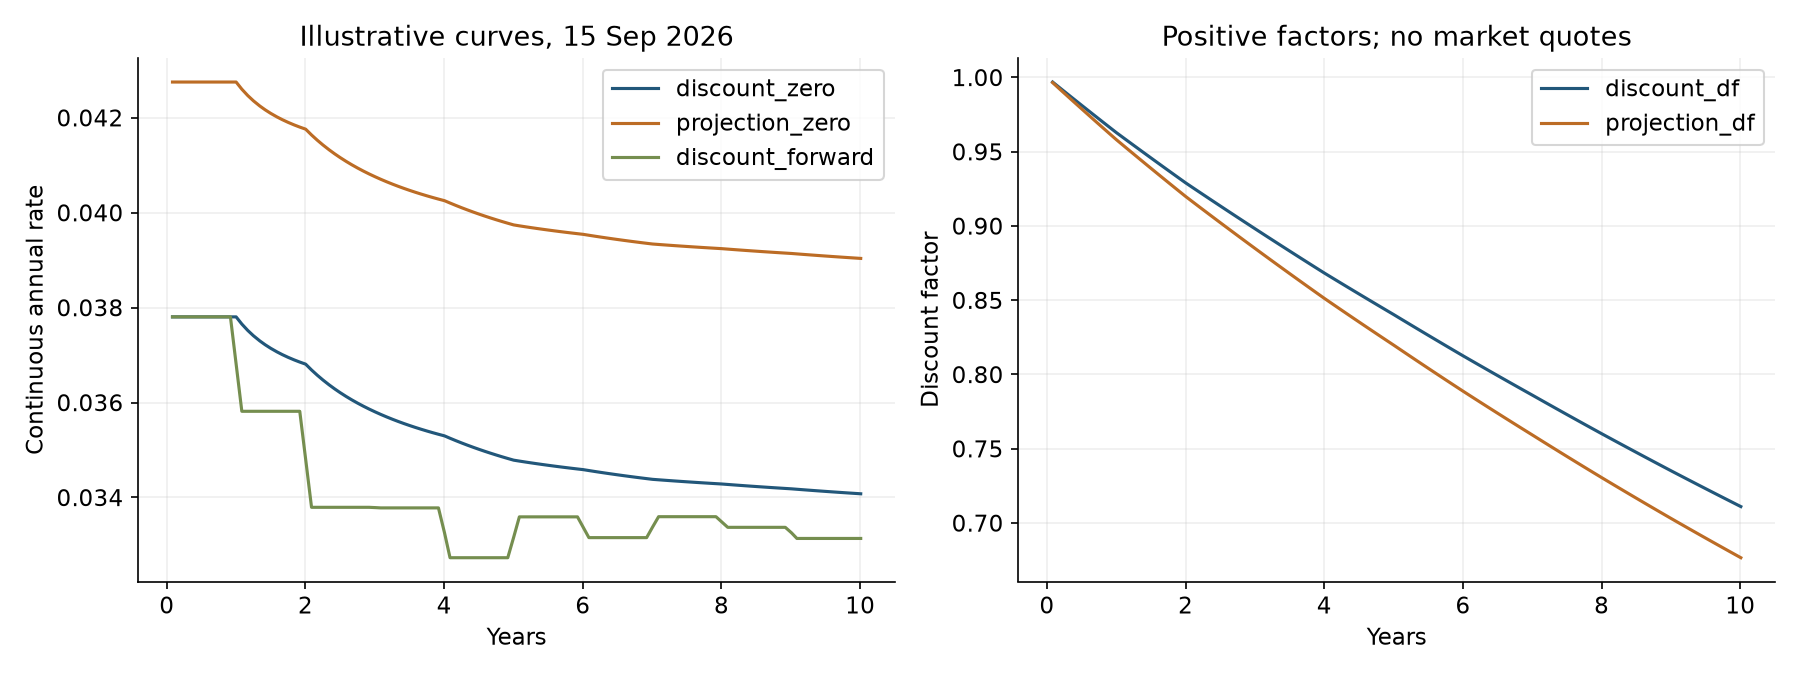

In [10]:
display(Image(filename=str(FIGURES / "curves.png")))

### Calibration

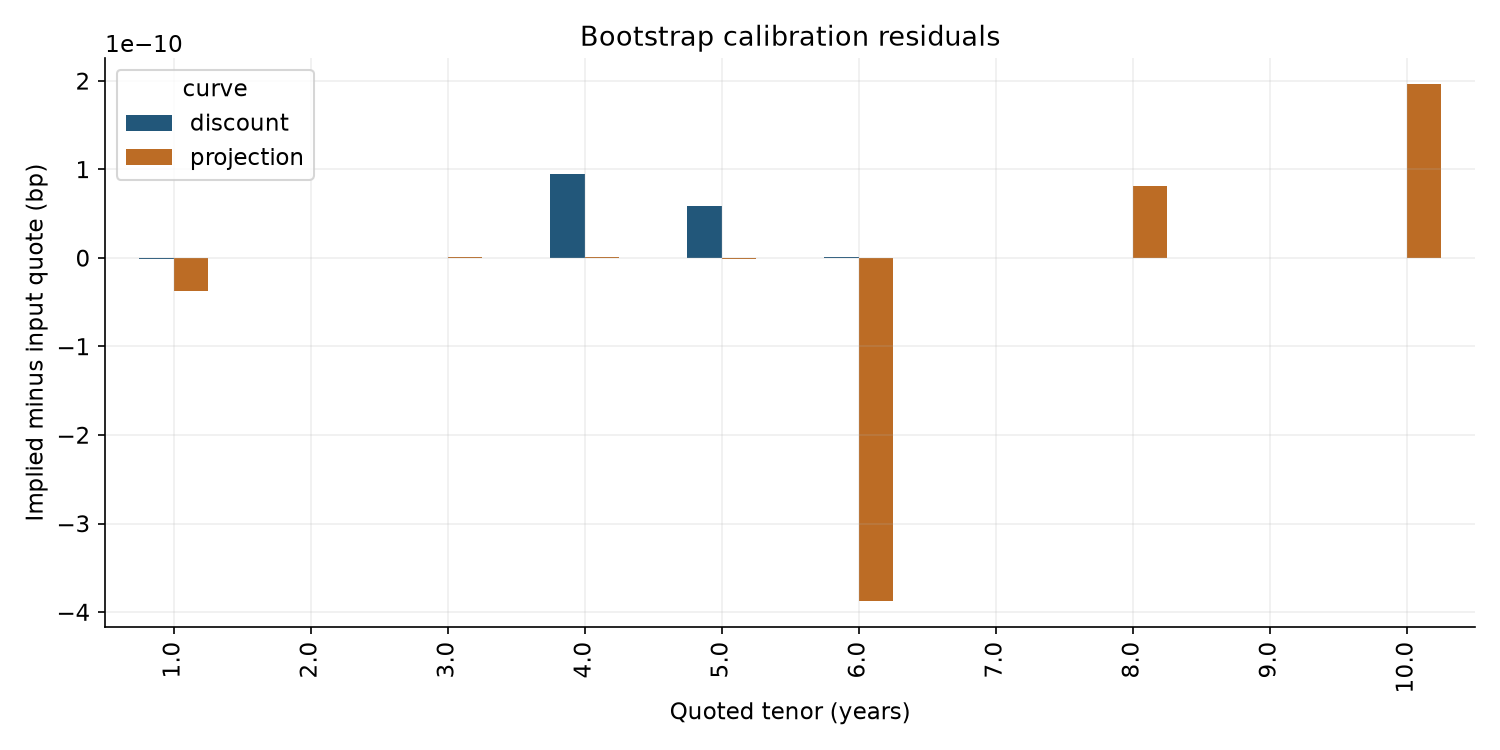

In [11]:
display(Image(filename=str(FIGURES / "calibration.png")))

### Risk

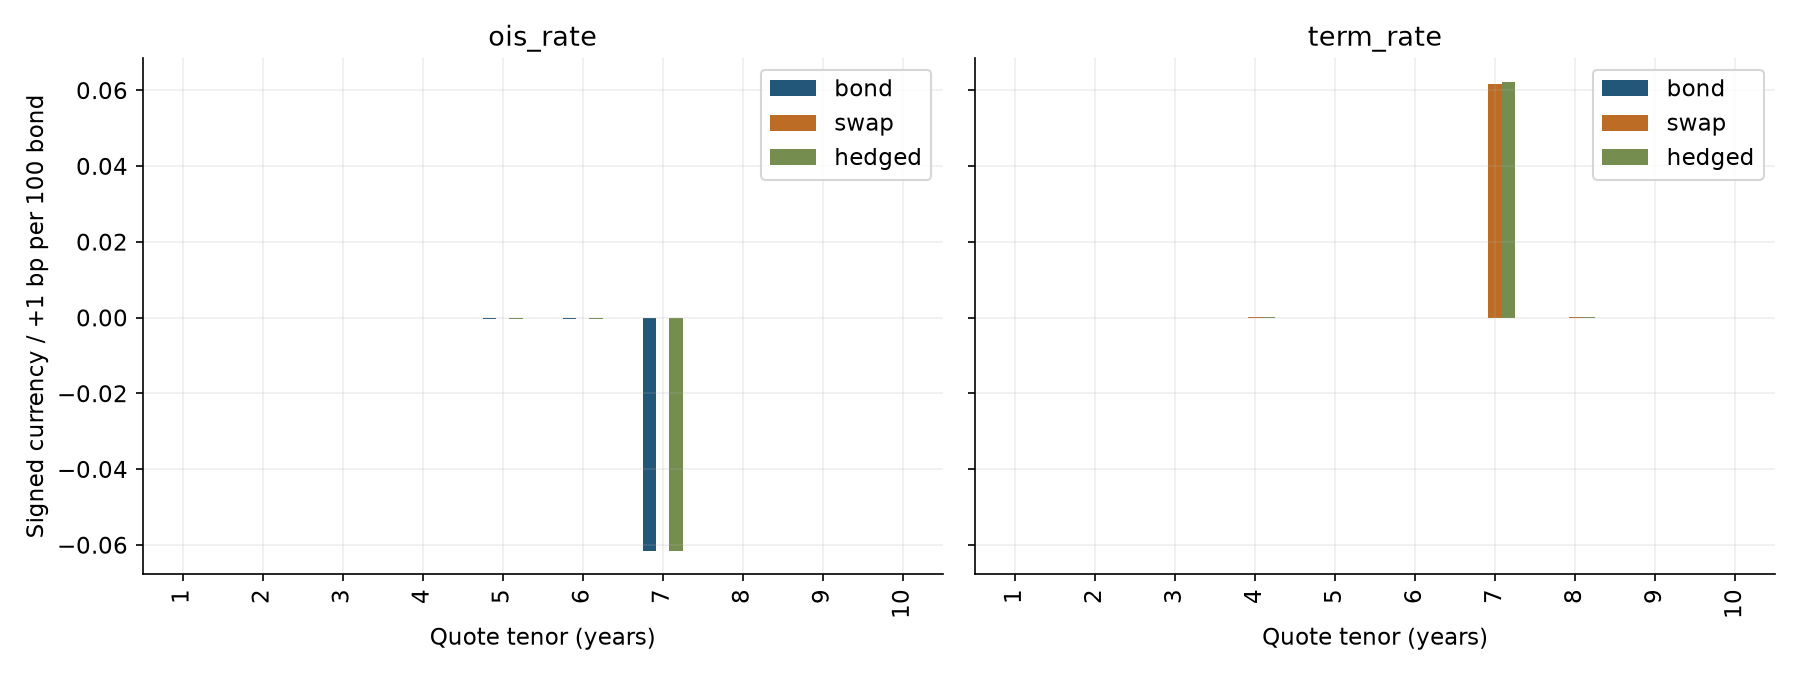

In [12]:
display(Image(filename=str(FIGURES / "risk.png")))

### Hedge

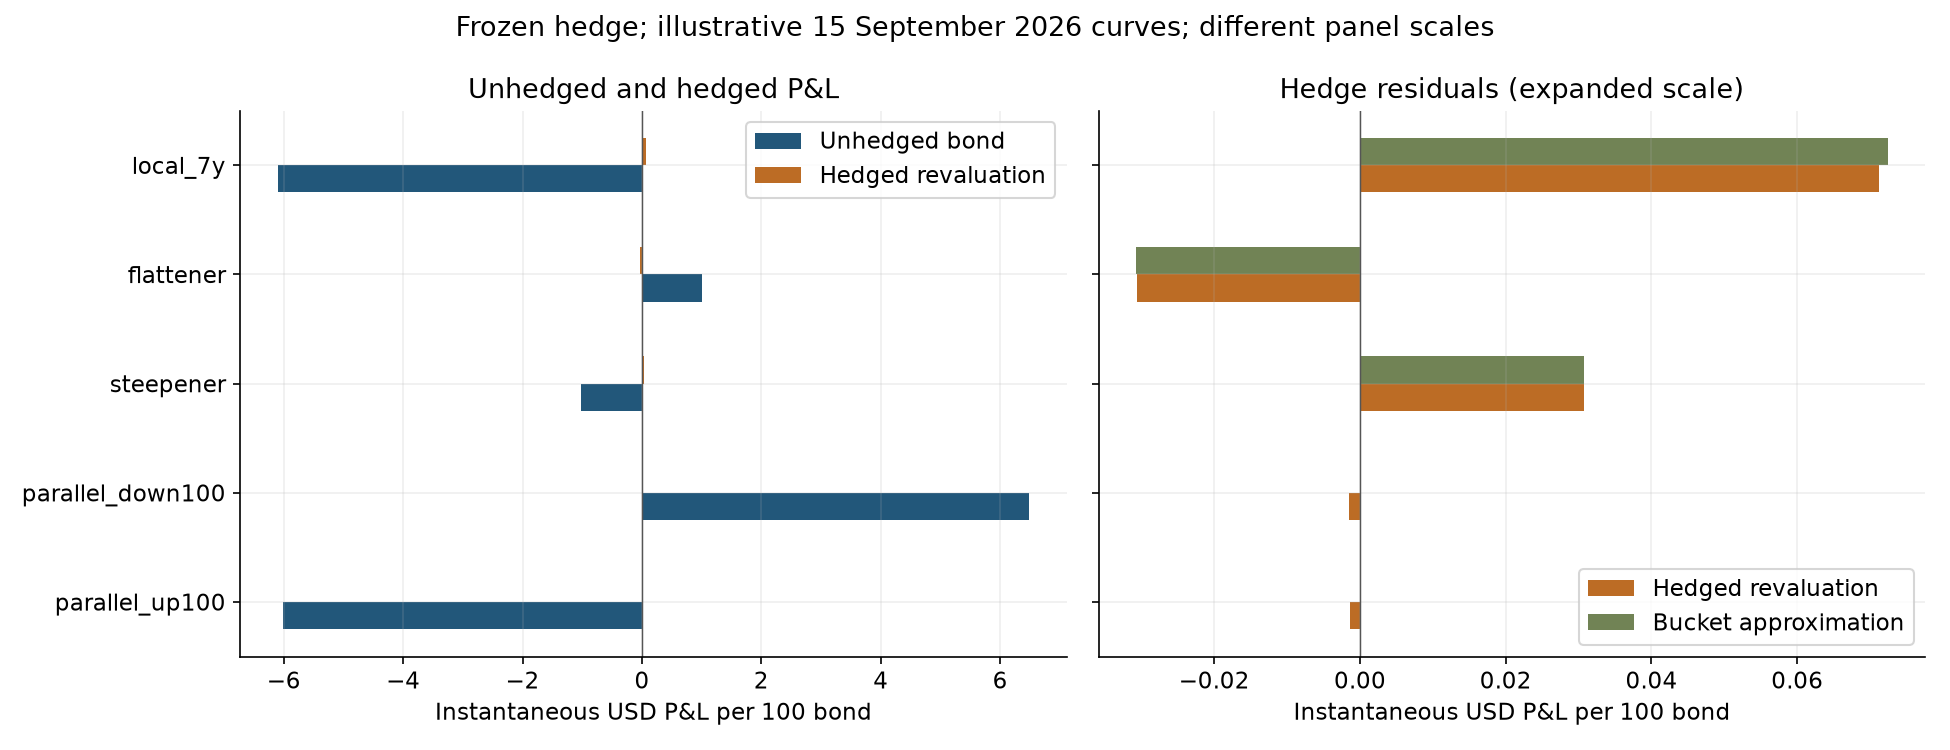

In [13]:
display(Image(filename=str(FIGURES / "hedge.png")))

## Calculation appendix

Independently reconstruct headline values and accounting identities from saved underlying outputs, then verify source/code/artifact hashes.

In [14]:
from research.check_artifacts import independent_checks
independent_checks()

Independent saved-output calculations and source/code hashes: passed


## Takeaways and next experiment

# Next experiment — explicitly not run

Numerical internal consistency is established, but replacing projection with discounting changes swap PV materially. Next, obtain a dated permitted OIS/term/basis quote set and contract/CSA/fixing conventions, then rerun independent repricing, quote risk and hedge scenarios including bid/ask and time passage. Only then assess market discrepancies. CDS additionally needs credit/recovery/default-accrual conventions and executable spread inputs; cross-currency swaps need basis, reset and collateral terms. These extensions have not been run.


See [source register](research/SOURCES.md), [audit](research/AUDIT.md), [protocol](research/PROTOCOL.md) and [publication review](PUBLICATION.md). No live publication is part of this build.